In [2]:
import os
import cv2
import random
import numpy as np
from tqdm import tqdm

In [2]:
def add_gaussian_noise(image, sigma_range=(10,30)):

    sigma = random.uniform(*sigma_range)

    noise = np.random.normal(
        0,
        sigma,
        image.shape
    )

    noisy = image.astype(np.float32) + noise

    noisy = np.clip(
        noisy,
        0,
        255
    )

    return noisy.astype(np.uint8)   

In [3]:
def add_salt_pepper_noise(
    image,
    amount_range=(0.002,0.01)
):

    output = image.copy()

    amount = random.uniform(
        *amount_range
    )

    num_pixels = int(
        amount * image.shape[0] * image.shape[1]
    )

    # salt
    coords = (
        np.random.randint(
            0,
            image.shape[0],
            num_pixels
        ),
        np.random.randint(
            0,
            image.shape[1],
            num_pixels
        )
    )

    output[coords] = 255

    # pepper
    coords = (
        np.random.randint(
            0,
            image.shape[0],
            num_pixels
        ),
        np.random.randint(
            0,
            image.shape[1],
            num_pixels
        )
    )

    output[coords] = 0

    return output

In [4]:
def add_blur(image):

    kernel = random.choice(
        [3,5,7]
    )

    return cv2.GaussianBlur(
        image,
        (kernel,kernel),
        0
    )

In [5]:
def add_fading(image):

    alpha = random.uniform(
        0.6,
        0.9
    )

    faded = cv2.convertScaleAbs(
        image,
        alpha=alpha,
        beta=20
    )

    return faded

In [6]:
def add_scratches(
    image,
    num_range=(5,20)
):

    damaged = image.copy()

    h,w = damaged.shape[:2]

    num_lines = random.randint(
        *num_range
    )

    for _ in range(num_lines):

        x1 = random.randint(0,w-1)
        y1 = random.randint(0,h-1)

        x2 = random.randint(0,w-1)
        y2 = random.randint(0,h-1)

        thickness = random.randint(
            1,
            2
        )

        color = random.randint(
            180,
            255
        )

        cv2.line(
            damaged,
            (x1,y1),
            (x2,y2),
            (color,color,color),
            thickness
        )

    return damaged

In [7]:
def add_crease(image):

    damaged = image.copy()

    h,w = damaged.shape[:2]

    x1 = random.randint(
        int(w*0.1),
        int(w*0.9)
    )

    y1 = 0

    x2 = random.randint(
        int(w*0.1),
        int(w*0.9)
    )

    y2 = h

    cv2.line(
        damaged,
        (x1,y1),
        (x2,y2),
        (255,255,255),
        random.randint(3,8)
    )

    damaged = cv2.GaussianBlur(
        damaged,
        (5,5),
        0
    )

    return damaged

In [8]:
def add_dust(image,
             num_spots_range=(50,200)):

    damaged = image.copy()

    h, w = damaged.shape[:2]

    num_spots = random.randint(
        *num_spots_range
    )

    for _ in range(num_spots):

        x = random.randint(0, w-1)
        y = random.randint(0, h-1)

        radius = random.randint(1, 3)

        color = random.randint(180,255)

        cv2.circle(
            damaged,
            (x,y),
            radius,
            (color,color,color),
            -1
        )

    return damaged

In [9]:
def add_stain(image,
              num_stains=5):

    damaged = image.copy()

    h,w = damaged.shape[:2]

    overlay = damaged.copy()

    for _ in range(num_stains):

        center = (
            random.randint(0,w),
            random.randint(0,h)
        )

        radius = random.randint(
            20,
            60
        )

        color = (
            random.randint(120,180),
            random.randint(120,180),
            random.randint(120,180)
        )

        cv2.circle(
            overlay,
            center,
            radius,
            color,
            -1
        )

    alpha = 0.2

    damaged = cv2.addWeighted(
        overlay,
        alpha,
        damaged,
        1-alpha,
        0
    )

    return damaged

In [10]:
def add_yellowing(image):

    damaged = image.astype(
        np.float32
    )

    damaged[:,:,0] *= 0.85
    damaged[:,:,1] *= 0.95
    damaged[:,:,2] *= 1.15

    damaged = np.clip(
        damaged,
        0,
        255
    )

    return damaged.astype(
        np.uint8
    )

In [11]:
def add_vignette(image):

    rows, cols = image.shape[:2]

    kernel_x = cv2.getGaussianKernel(
        cols,
        cols/2
    )

    kernel_y = cv2.getGaussianKernel(
        rows,
        rows/2
    )

    kernel = kernel_y @ kernel_x.T

    mask = kernel / kernel.max()

    output = np.copy(
        image
    )

    for i in range(3):

        output[:,:,i] = (
            output[:,:,i] * mask
        )

    return output.astype(
        np.uint8
    )

In [12]:
def add_tear(image):

    damaged = image.copy()

    h,w = damaged.shape[:2]

    x1 = random.randint(
        0,
        w//2
    )

    y1 = random.randint(
        0,
        h
    )

    x2 = x1 + random.randint(
        30,
        80
    )

    y2 = y1 + random.randint(
        -50,
        50
    )

    cv2.line(
        damaged,
        (x1,y1),
        (x2,y2),
        (255,255,255),
        10
    )

    return damaged

In [13]:
def add_missing_region(image):

    damaged = image.copy()

    h,w = damaged.shape[:2]

    x = random.randint(
        0,
        int(w*0.7)
    )

    y = random.randint(
        0,
        int(h*0.7)
    )

    width = random.randint(
        20,
        80
    )

    height = random.randint(
        20,
        80
    )

    cv2.rectangle(
        damaged,
        (x,y),
        (x+width,y+height),
        (255,255,255),
        -1
    )

    return damaged

In [14]:
def add_sepia(image):

    kernel = np.array([
        [0.272,0.534,0.131],
        [0.349,0.686,0.168],
        [0.393,0.769,0.189]
    ])

    sepia = cv2.transform(
        image,
        kernel
    )

    return np.clip(
        sepia,
        0,
        255
    ).astype(np.uint8)

In [15]:
def create_old_photo_damage(image):

    damaged = image.copy()

    aging_effects = [
        add_yellowing,
        add_sepia,
        add_fading
    ]

    quality_effects = [
        add_blur,
        add_gaussian_noise,
        add_salt_pepper_noise
    ]

    physical_effects = [
        add_dust,
        add_scratches,
        add_crease,
        add_stain,
        add_tear,
        add_missing_region
    ]

    scan_effects = [
        add_vignette
    ]

    # Aging
    for effect in random.sample(
        aging_effects,
        random.randint(1, len(aging_effects))
    ):
        damaged = effect(damaged)

    # Quality
    for effect in random.sample(
        quality_effects,
        random.randint(1, len(quality_effects))
    ):
        damaged = effect(damaged)

    # Physical
    for effect in random.sample(
        physical_effects,
        random.randint(2, 5)
    ):
        damaged = effect(damaged)

    # Scan artifact
    if random.random() < 0.5:
        damaged = add_vignette(damaged)

    return damaged

In [4]:
SOURCE_DIR = "raw"

CLEAN_DIR = "dataset/clean"

DAMAGED_DIR = "dataset/damaged"

os.makedirs(
    CLEAN_DIR,
    exist_ok=True
)

os.makedirs(
    DAMAGED_DIR,
    exist_ok=True
)

In [19]:
files = [
    f for f in os.listdir(SOURCE_DIR)
    if f.lower().endswith(
        (".jpg",".jpeg",".png")
    )
]

print(
    f"Found {len(files)} images"
)

for filename in tqdm(files):

    path = os.path.join(
        SOURCE_DIR,
        filename
    )

    image = cv2.imread(path)

    if image is None:
        continue

    image = cv2.resize(
        image,
        (256,256)
    )

    damaged = create_old_photo_damage(
        image
    )

    cv2.imwrite(
        os.path.join(
            CLEAN_DIR,
            filename
        ),
        image
    )

    cv2.imwrite(
        os.path.join(
            DAMAGED_DIR,
            filename
        ),
        damaged
    )

print("Dataset generation complete")

Found 3143 images


  0%|          | 0/3143 [00:00<?, ?it/s]

100%|██████████| 3143/3143 [02:31<00:00, 20.77it/s]

Dataset generation complete


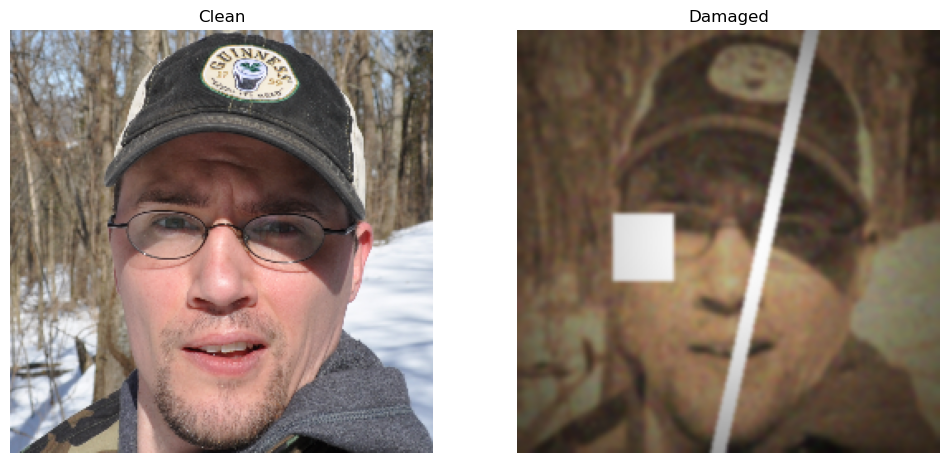

In [8]:
sample = random.choice(
    os.listdir(CLEAN_DIR)
)

clean = cv2.imread(
    os.path.join(
        CLEAN_DIR,
        sample
    )
)

damaged = cv2.imread(
    os.path.join(
        DAMAGED_DIR,
        sample
    )
)

clean = cv2.cvtColor(
    clean,
    cv2.COLOR_BGR2RGB
)

damaged = cv2.cvtColor(
    damaged,
    cv2.COLOR_BGR2RGB
)

import matplotlib.pyplot as plt

fig, ax = plt.subplots(
    1,
    2,
    figsize=(12,6)
)

ax[0].imshow(clean)
ax[0].set_title("Clean")
ax[0].axis("off")

ax[1].imshow(damaged)
ax[1].set_title("Damaged")
ax[1].axis("off")

plt.show()

**DATA SPLIT**

In [22]:
import os
import shutil
import random
from sklearn.model_selection import train_test_split

In [23]:
CLEAN_DIR = "dataset/clean"
DAMAGED_DIR = "dataset/damaged"

OUTPUT_DIR = "dataset_split"

TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

SEED = 42

In [24]:
for split in ["train", "val", "test"]:

    os.makedirs(
        os.path.join(
            OUTPUT_DIR,
            split,
            "clean"
        ),
        exist_ok=True
    )

    os.makedirs(
        os.path.join(
            OUTPUT_DIR,
            split,
            "damaged"
        ),
        exist_ok=True
    )

In [25]:
files = sorted([
    f for f in os.listdir(CLEAN_DIR)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png")
    )
])

print(
    f"Total images: {len(files)}"
)

Total images: 3143


In [26]:
train_files, temp_files = train_test_split(
    files,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=SEED
)

val_files, test_files = train_test_split(
    temp_files,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    random_state=SEED
)

print("Train :", len(train_files))
print("Val   :", len(val_files))
print("Test  :", len(test_files))

Train : 2200
Val   : 471
Test  : 472


In [27]:
def copy_pair(file_list, split_name):

    for filename in file_list:

        src_clean = os.path.join(
            CLEAN_DIR,
            filename
        )

        src_damaged = os.path.join(
            DAMAGED_DIR,
            filename
        )

        dst_clean = os.path.join(
            OUTPUT_DIR,
            split_name,
            "clean",
            filename
        )

        dst_damaged = os.path.join(
            OUTPUT_DIR,
            split_name,
            "damaged",
            filename
        )

        shutil.copy2(
            src_clean,
            dst_clean
        )

        shutil.copy2(
            src_damaged,
            dst_damaged
        )

In [28]:
copy_pair(
    train_files,
    "train"
)

copy_pair(
    val_files,
    "val"
)

copy_pair(
    test_files,
    "test"
)

print("Dataset split completed.")

Dataset split completed.


In [29]:
for split in ["train","val","test"]:

    clean_count = len(
        os.listdir(
            os.path.join(
                OUTPUT_DIR,
                split,
                "clean"
            )
        )
    )

    damaged_count = len(
        os.listdir(
            os.path.join(
                OUTPUT_DIR,
                split,
                "damaged"
            )
        )
    )

    print(
        f"{split}: "
        f"{clean_count} clean | "
        f"{damaged_count} damaged"
    )

train: 2200 clean | 2200 damaged
val: 471 clean | 471 damaged
test: 472 clean | 472 damaged
